In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error

In [2]:
data_dir = './DATA/'
filename = '2023_clean.csv'

In [3]:
df_raw = pd.read_csv(f'{data_dir}{filename}')
df_raw

,latitude,longitude,epa_o3,aster_dem,cams_col_o3,cams_surf_o3,cams_surf_no2,cams_surf_hcho,ceres_swf_all,era5_blh,...,era5_u10,era5_v10,modis_landtype,water_fraction,modis_ndvi,pop,viirs_ntl,doy,year,era5_t2m-d2m
0,25.58733,-80.32592,47.0,8.50,0.005805,57.70011,3.728535,0.898007,98.90685,838.2379,...,-3.377644,-4.859169,13.0,0.816232,4955.9390,971.0,29.19848,74,2023,6.1400
1,25.73288,-80.16175,52.0,6.00,0.005815,57.76892,3.325275,0.821489,97.68685,920.1100,...,-3.799672,-5.606412,17.0,0.814599,0.0000,541.0,25.49089,74,2023,6.5117
2,26.05389,-80.25694,49.0,7.25,0.005835,56.46091,3.421305,0.866421,106.24270,813.9014,...,-2.508782,-4.457390,13.0,0.804572,4404.9160,2260.0,42.33829,74,2023,7.3543
3,26.07354,-80.33845,45.0,6.75,0.005835,56.10865,3.300170,0.913606,108.91690,774.0244,...,-2.081585,-3.917842,13.0,0.802612,5528.4330,248.0,10.97885,74,2023,7.5945
4,26.08757,-80.11115,49.0,4.75,0.005839,57.03552,2.849112,0.798274,102.68090,900.7109,...,-2.786024,-4.935722,11.0,0.806499,2073.2290,507.0,24.97562,74,2023,7.0789
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375363,48.29786,-124.62490,41.0,347.00,0.006828,42.42863,2.840825,0.799792,28.79292,566.4708,...,-2.415503,3.799192,1.0,0.183671,9151.0060,0.0,0.00000,309,2023,1.1626
375364,48.31751,-107.86250,35.0,750.75,0.006223,35.88940,1.632936,0.306875,53.67106,516.4257,...,4.925898,-0.016392,10.0,0.005111,-112.3374,0.0,0.00000,309,2023,6.2553
375365,48.41252,-92.82922,26.0,381.50,0.005994,36.50267,1.656441,0.266633,33.74514,493.7099,...,-2.505063,1.472806,8.0,0.111941,4976.9830,0.0,0.00000,309,2023,1.8844
375366,48.51030,-113.99680,34.0,971.00,0.006467,42.23070,2.121162,0.308139,66.52199,500.4874,...,0.949018,0.962373,8.0,0.007666,2393.2220,14.0,0.00000,309,2023,1.6947


In [6]:
# define the target
target = "epa_o3"

# define the features used in the training
feature_cols = [
    "latitude", "longitude",
    "aster_dem",
    "cams_col_o3", "cams_surf_o3", "cams_surf_no2", "cams_surf_hcho",
    "ceres_swf_all",
    "era5_blh", "era5_t2m", "era5_u10", "era5_v10", "era5_t2m-d2m",
    "modis_landtype", "water_fraction", "modis_ndvi",
    "pop", "viirs_ntl",
    "doy", "year"
]

# Keep only columns needed for this demo
data = df_raw[feature_cols + [target]].copy()

# Drop rows without EPA ozone observation
data = data.dropna(subset=[target])

X = data[feature_cols]
y = data[target]

In [8]:
# Random split for simple demonstration
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [9]:
categorical_features = ["modis_landtype"]

numeric_features = [c for c in feature_cols if c not in categorical_features]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

rf_model = RandomForestRegressor(
    n_estimators=300,        # Number of decision trees in the forest.
    max_depth=25,            # Maximum depth of each individual tree; Deeper trees can capture complex nonlinear relationships
    min_samples_leaf=5,      # Minimum number of samples required in each terminal leaf node; Larger values make the model smoother and less sensitive to noise.
    random_state=42,         # Fixes the random seed so that the same forest is produced each time.
    n_jobs=-1, 
    oob_score=True
)

model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("rf", rf_model)
    ]
)

model.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [11]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mb = np.mean(y_pred - y_test)

print(f"R$^2$   = {r2:.3f}")
print(f"RMSE = {rmse:.3f}")
print(f"MAE  = {mae:.3f}")
print(f"MB   = {mb:.3f}")
print(f"OOB R$^2$ = {model.named_steps['rf'].oob_score_:.3f}")

R$^2$   = 0.860
RMSE = 4.584
MAE  = 3.293
MB   = -0.006
OOB R$^2$ = 0.858


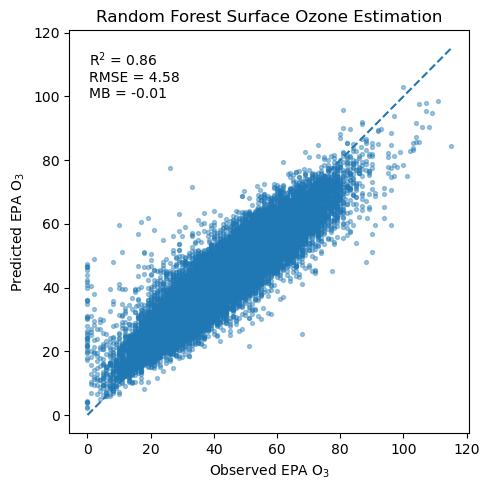

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred, s=8, alpha=0.4)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Observed EPA O$_3$")
plt.ylabel("Predicted EPA O$_3$")
plt.title("Random Forest Surface Ozone Estimation")
plt.text(
    0.05, 0.95,
    f"R$^2$ = {r2:.2f}\nRMSE = {rmse:.2f}\nMB = {mb:.2f}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.tight_layout()
plt.show()

In [13]:
preprocess = model.named_steps["preprocess"]
rf = model.named_steps["rf"]

# Numeric features do not change names after imputation
num_names = numeric_features

# Categorical features are expanded by one-hot encoding
cat_pipeline = preprocess.named_transformers_["cat"]
onehot = cat_pipeline.named_steps["onehot"]

try:
    cat_names = onehot.get_feature_names_out(categorical_features)
except AttributeError:
    # For older sklearn versions
    cat_names = onehot.get_feature_names(categorical_features)

# Combine names in the same order as ColumnTransformer output
feature_names = np.concatenate([num_names, cat_names])

importances = rf.feature_importances_

print(len(feature_names), len(importances))

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df.head(20)

34 34


,feature,importance
4,cams_surf_o3,0.532308
7,ceres_swf_all,0.070058
1,longitude,0.055763
2,aster_dem,0.055154
17,doy,0.049987
0,latitude,0.025599
12,era5_t2m-d2m,0.024025
5,cams_surf_no2,0.022275
11,era5_v10,0.021177
6,cams_surf_hcho,0.021107


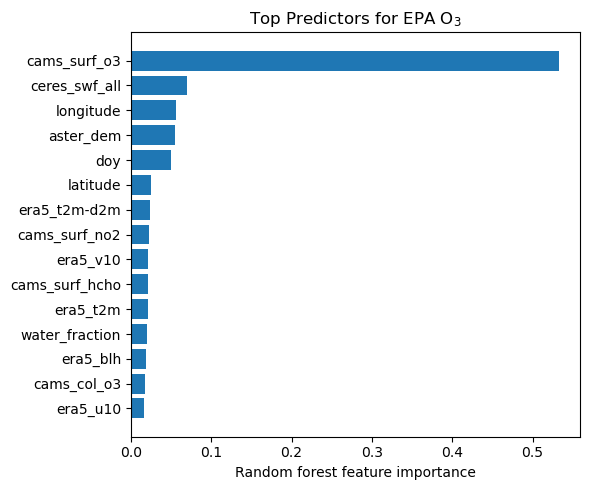

In [14]:
import matplotlib.pyplot as plt

top_n = 15
plot_df = importance_df.head(top_n).iloc[::-1]

plt.figure(figsize=(6, 5))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.xlabel("Random forest feature importance")
plt.title("Top Predictors for EPA O$_3$")
plt.tight_layout()
plt.show()

In [22]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=1,
    scoring="r2"
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

perm_df.head(20)

,feature,importance_mean,importance_std
4,cams_surf_o3,0.716390,0.003410
7,ceres_swf_all,0.181013,0.000606
1,longitude,0.163933,0.001894
18,doy,0.128355,0.000887
2,aster_dem,0.112266,0.001363
0,latitude,0.050057,0.000624
14,water_fraction,0.034421,0.000305
12,era5_t2m-d2m,0.033302,0.000432
9,era5_t2m,0.031367,0.000522
5,cams_surf_no2,0.029440,0.000213


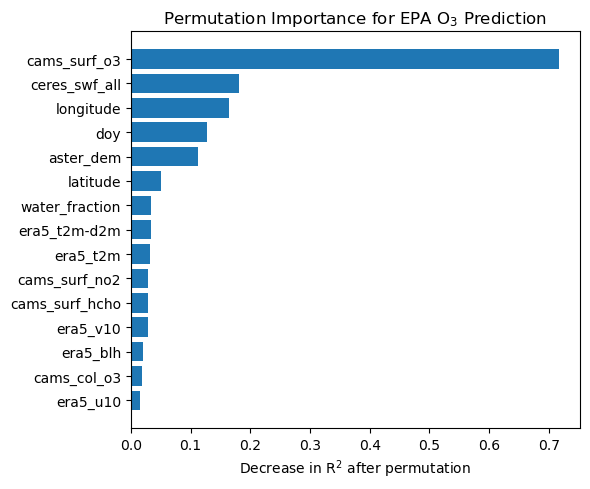

In [23]:
import matplotlib.pyplot as plt

plot_df = perm_df.head(15).iloc[::-1]

plt.figure(figsize=(6, 5))
plt.barh(plot_df["feature"], plot_df["importance_mean"])
plt.xlabel("Decrease in R$^2$ after permutation")
plt.title("Permutation Importance for EPA O$_3$ Prediction")
plt.tight_layout()
plt.show()